In [20]:
import numpy as np
np.set_printoptions(threshold=100000, linewidth=100000)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

import pandas as pd
import sklearn
import matplotlib.pyplot as plt

In [21]:
import datetime
def write_csv_file(y_pred :np.ndarray):
    '''Write csv file from numpy array y_pred'''
    now_string = (datetime.datetime.now()-datetime.timedelta(hours=3)).strftime("%d-%m_%H-%M-%S")
    
    output_df = pd.DataFrame([f'CPMG_{i:03d}.csv' for i in range(1000)], columns=['CPMG'])
    output_df['%'] = y_pred#.squeeze().detach().cpu().numpy()
    output_df.to_csv("time2_trilha1_"+now_string+".csv", sep="\t", index=False)
    return output_df

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [4]:
train_df = pd.read_csv('data_train_DWT_n.csv', sep="\t")
test_df = pd.read_csv('data_test_DWT_n.csv', sep="\t")

### Rodando com 500 primeiros datapoints

In [5]:
n_init_points = 500
short_train_df = train_df.iloc[:,:n_init_points].copy()
short_train_df['y'] = train_df['y']
short_test_df = test_df.iloc[:,:n_init_points].copy()
# short_train_df

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(short_train_df.iloc[:,:n_init_points]))
y = torch.Tensor(np.array(short_train_df['y']).reshape(-1,1))

X = X.to(device)
y = y.to(device)

trainDs, valDs = random_split(TensorDataset(X, y), [.8,.2])
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

Device is cuda


In [7]:
model = nn.Sequential(
    nn.Linear(n_init_points,256),
    nn.ReLU(),
    nn.Linear(256,128),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.053842 | Val MSE: 0.048040
Epoch 10 | Train MSE: 0.016841 | Val MSE: 0.015871
Epoch 20 | Train MSE: 0.012590 | Val MSE: 0.011164
Epoch 30 | Train MSE: 0.011122 | Val MSE: 0.009945
Epoch 40 | Train MSE: 0.009577 | Val MSE: 0.008928
Epoch 50 | Train MSE: 0.009558 | Val MSE: 0.009633
Epoch 60 | Train MSE: 0.008582 | Val MSE: 0.009923
Epoch 70 | Train MSE: 0.008424 | Val MSE: 0.008068
Epoch 80 | Train MSE: 0.008662 | Val MSE: 0.008027
Epoch 90 | Train MSE: 0.009979 | Val MSE: 0.009103


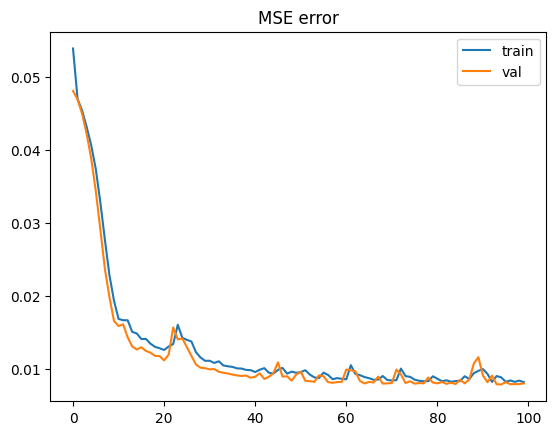

In [8]:
epochs = 100  #20
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%10==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.08956547 R²: 0.85350066 MAE: 0.07007485


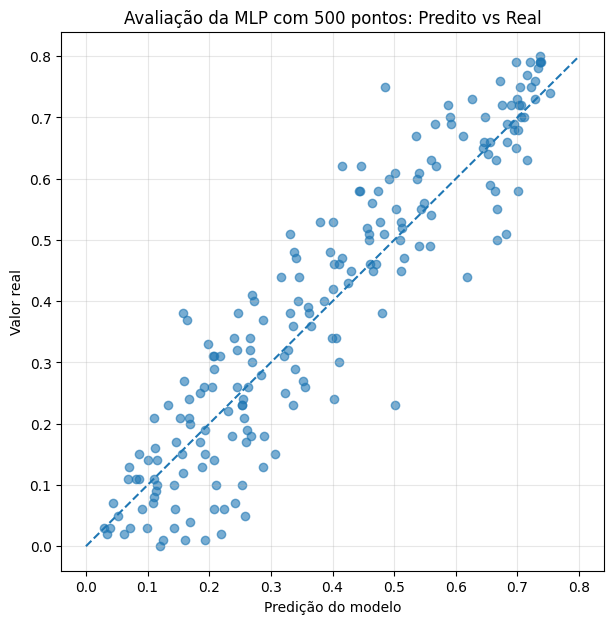

In [9]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title(f"Avaliação da MLP com {n_init_points} pontos: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [209]:
write_csv_file(y_pred.squeeze().detach().cpu().numpy())

,CPMG,%
0,CPMG_000.csv,0.386244
1,CPMG_001.csv,0.694590
2,CPMG_002.csv,0.217418
3,CPMG_003.csv,0.326525
4,CPMG_004.csv,0.102075
...,...,...
995,CPMG_995.csv,0.217330
996,CPMG_996.csv,0.735972
997,CPMG_997.csv,0.179982
998,CPMG_998.csv,0.328672


### Fazendo PCA

In [10]:
train_df = pd.read_csv('data_train_DWT_n.csv', sep="\t")
test_df = pd.read_csv('data_test_DWT_n.csv', sep="\t")

In [11]:
pca = sklearn.decomposition.PCA(n_components=.95)
pca.fit(train_df.iloc[:,:-1])

,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [12]:
train_df_pca = pd.DataFrame(pca.transform(train_df.iloc[:,:-1]))
train_df_pca['y'] = train_df['y']
test_df_pca = pd.DataFrame(pca.transform(test_df))
# train_df_pca.to_csv("data_train_PCA.csv", sep="\t")
# test_df_pca.to_csv("data_test_PCA.csv", sep="\t")
train_df_pca

,0,1,2,y
0,0.579692,0.152626,0.038465,0.29
1,0.593802,0.214637,0.059299,0.30
2,0.889421,0.127131,-0.165317,0.11
3,-0.975562,0.008256,-0.081958,0.61
4,-1.256180,-0.253391,-0.003073,0.74
...,...,...,...,...
995,0.155068,-0.089758,-0.036257,0.33
996,-0.413799,0.056786,-0.092782,0.29
997,-0.354801,-0.344260,-0.130231,0.36
998,-0.824090,0.023643,-0.090933,0.69


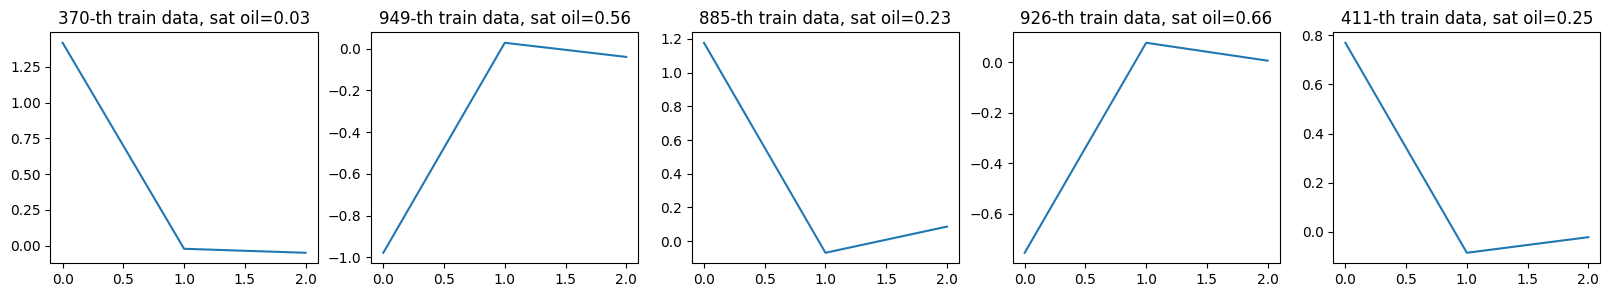

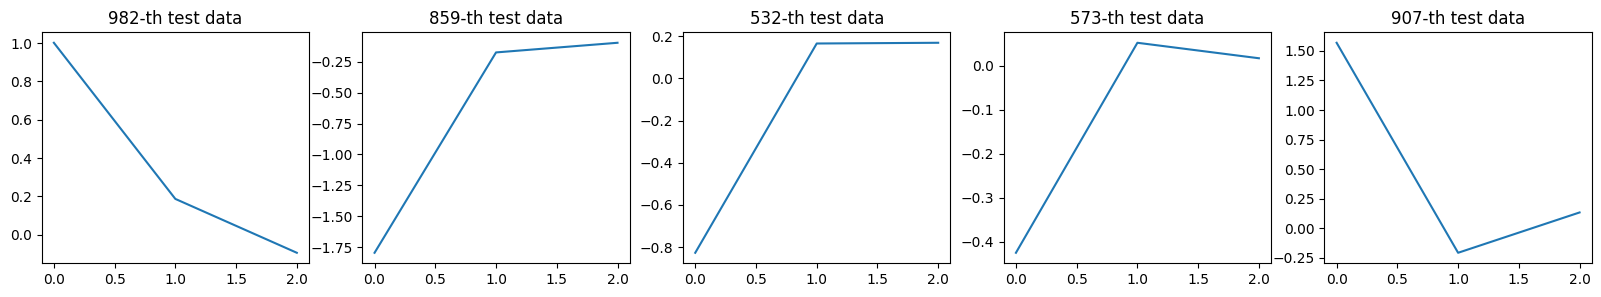

In [13]:
'''Plot graph of test and train after PCA'''
# set_seed(seed)
fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(train_df_pca.loc[j].values[:-1])
    ax[i].set_title(f"{j}-th train data, sat oil={train_df_pca.iloc[j,-1]}")
plt.show();

fig, ax = plt.subplots(1,5, figsize=(20,3))
for i in range(5):
    j = np.random.randint(1,1000)
    ax[i].plot(test_df_pca.loc[j].values)
    ax[i].set_title(f"{j}-th test data")
plt.show();

In [15]:
# set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device is {device}")

X = torch.Tensor(np.array(train_df_pca.iloc[:,:-1]))
y = torch.Tensor(np.array(train_df_pca['y']).reshape(-1,1))

X = X.to(device)
y = y.to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)

Device is cuda


In [16]:
model = nn.Sequential(
    nn.Linear(X.shape[1],256),
    nn.ReLU(),
    nn.Linear(256,128),
    # nn.ReLU(),
    # nn.Linear(128,32),
    nn.ReLU(),
    nn.Linear(128,1),
    nn.Sigmoid(),).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 00 | Train MSE: 0.041037 | Val MSE: 0.018183
Epoch 05 | Train MSE: 0.012381 | Val MSE: 0.011265
Epoch 10 | Train MSE: 0.010295 | Val MSE: 0.009258
Epoch 15 | Train MSE: 0.009222 | Val MSE: 0.008393
Epoch 20 | Train MSE: 0.008449 | Val MSE: 0.007609
Epoch 25 | Train MSE: 0.007953 | Val MSE: 0.007202
Epoch 30 | Train MSE: 0.007969 | Val MSE: 0.007129
Epoch 35 | Train MSE: 0.007758 | Val MSE: 0.007140
Epoch 40 | Train MSE: 0.007722 | Val MSE: 0.007204
Epoch 45 | Train MSE: 0.007730 | Val MSE: 0.007178
Epoch 50 | Train MSE: 0.007796 | Val MSE: 0.007134
Epoch 55 | Train MSE: 0.007694 | Val MSE: 0.007182
Epoch 60 | Train MSE: 0.007770 | Val MSE: 0.007360
Epoch 65 | Train MSE: 0.007634 | Val MSE: 0.007227
Epoch 70 | Train MSE: 0.007616 | Val MSE: 0.007253


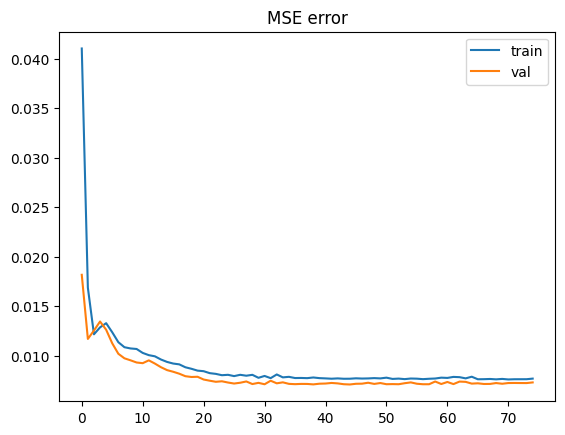

RMSE: 0.08552839 R²: 0.8632269 MAE: 0.06596026


In [17]:
# set_seed(seed)
epochs = 75
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

Epoch 00 | Train MSE: 0.055435 | Val MSE: 0.034510
Epoch 05 | Train MSE: 0.011426 | Val MSE: 0.010576
Epoch 10 | Train MSE: 0.009382 | Val MSE: 0.007955
Epoch 15 | Train MSE: 0.008497 | Val MSE: 0.007010
Epoch 20 | Train MSE: 0.007883 | Val MSE: 0.006413
Epoch 25 | Train MSE: 0.007557 | Val MSE: 0.006116
Epoch 30 | Train MSE: 0.007392 | Val MSE: 0.006121
Epoch 35 | Train MSE: 0.007337 | Val MSE: 0.006034
Epoch 40 | Train MSE: 0.007363 | Val MSE: 0.006015
Epoch 45 | Train MSE: 0.007254 | Val MSE: 0.006099
Epoch 50 | Train MSE: 0.007308 | Val MSE: 0.006092
Epoch 55 | Train MSE: 0.007160 | Val MSE: 0.006067
Epoch 60 | Train MSE: 0.007192 | Val MSE: 0.006138
Epoch 65 | Train MSE: 0.007121 | Val MSE: 0.006152
Epoch 70 | Train MSE: 0.007091 | Val MSE: 0.006409


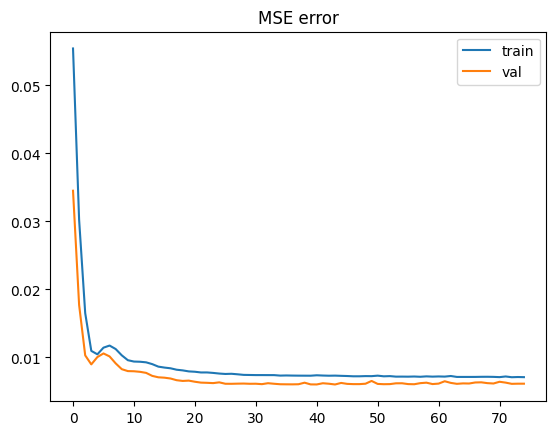

RMSE: 0.07826935 R²: 0.8880077 MAE: 0.060998324


In [143]:
epochs = 75
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

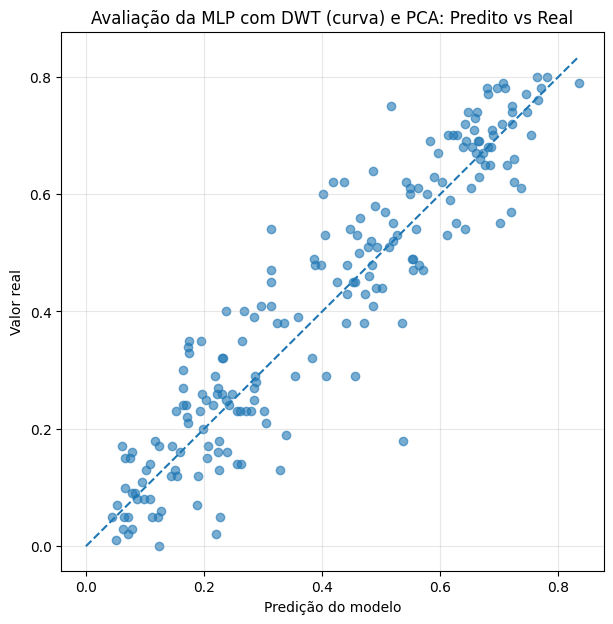

In [18]:
# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da MLP com DWT (curva) e PCA: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
Xtest = torch.Tensor(np.array(test_df_pca)).to(device)
model.eval()
with torch.no_grad():
    ytest_pred = model(Xtest).squeeze().detach().cpu().numpy()

write_csv_file(ytest_pred)

,CPMG,%
0,CPMG_000.csv,0.279444
1,CPMG_001.csv,0.705194
2,CPMG_002.csv,0.171291
3,CPMG_003.csv,0.345653
4,CPMG_004.csv,0.057689
...,...,...
995,CPMG_995.csv,0.206569
996,CPMG_996.csv,0.729670
997,CPMG_997.csv,0.138435
998,CPMG_998.csv,0.199901


Epoch 00 | Train MSE: 0.057504 | Val MSE: 0.038221
Epoch 05 | Train MSE: 0.013343 | Val MSE: 0.010150
Epoch 10 | Train MSE: 0.010598 | Val MSE: 0.009391
Epoch 15 | Train MSE: 0.009169 | Val MSE: 0.007706
Epoch 20 | Train MSE: 0.008455 | Val MSE: 0.007037
Epoch 25 | Train MSE: 0.008179 | Val MSE: 0.006978
Epoch 30 | Train MSE: 0.008041 | Val MSE: 0.006485
Epoch 35 | Train MSE: 0.008019 | Val MSE: 0.006644
Epoch 40 | Train MSE: 0.008130 | Val MSE: 0.006418
Epoch 45 | Train MSE: 0.007960 | Val MSE: 0.006439
Epoch 50 | Train MSE: 0.007913 | Val MSE: 0.006700
Epoch 55 | Train MSE: 0.007920 | Val MSE: 0.006330
Epoch 60 | Train MSE: 0.007953 | Val MSE: 0.006452
Epoch 65 | Train MSE: 0.008019 | Val MSE: 0.006461
Epoch 70 | Train MSE: 0.008117 | Val MSE: 0.006340


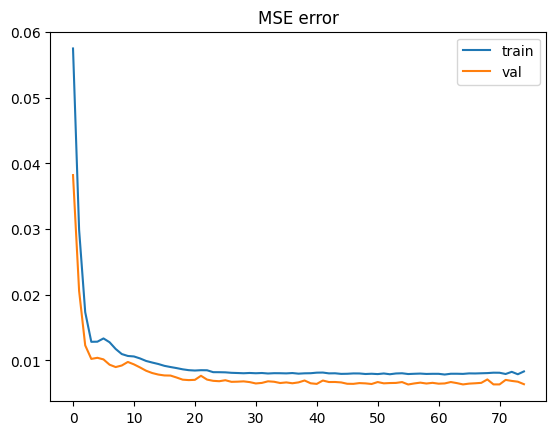

In [122]:
epochs = 75
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if epoch%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.07982877 R²: 0.8863217 MAE: 0.06206659


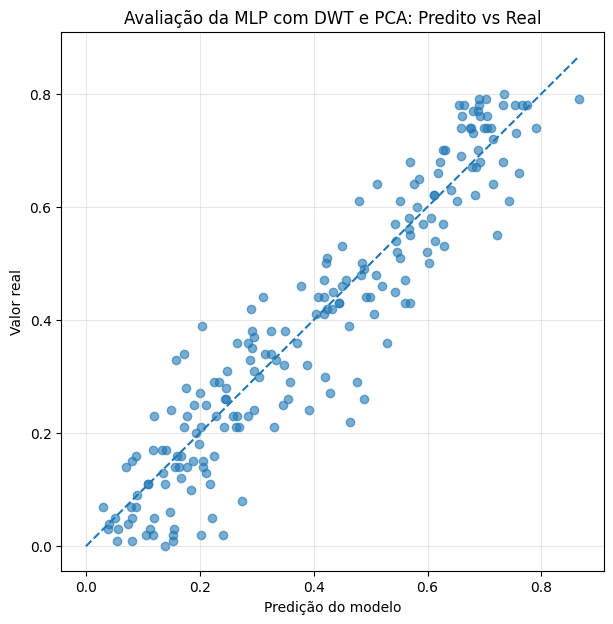

In [130]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da MLP com DWT e PCA: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

Agora com CatBoost

In [51]:
%pip install catboost

  Using cached catboost-1.2.8-cp310-cp310-manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.4.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached narwhals-2.11.0-py3-none-any.whl.metadata (11 kB)
Using cached catboost-1.2.8-cp310-cp310-manylinux2014_x86_64.whl (99.2 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached plotly-6.4.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.11.0-py3-none-any.whl (423 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [catboost]3/4 [catboost]
Note: you may need to restart the kernel to use updated packages.


## Catboost: training setup

In [33]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

n_init_points = 500
X = np.array(train_df.iloc[:,:n_init_points])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

model = CatBoostRegressor()
model.fit(Xtrain,ytrain, verbose=0, eval_set=(Xval,yval))

[(1000, 500), (1000,), (800, 500), (200, 500), (800,), (200,)]


RMSE: 0.08559393098229062 R²: 0.8722929891426145 MAE: 0.06888856027531214


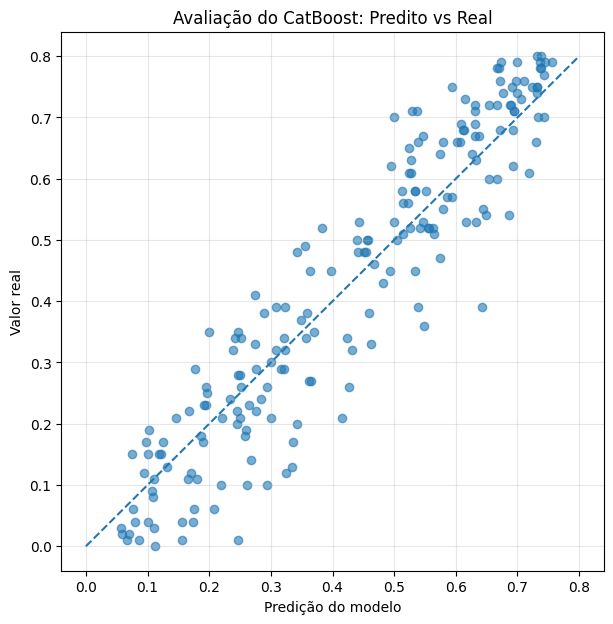

In [34]:
y_pred = model.predict(Xval)

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, yval, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação do CatBoost: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

In [196]:
Xtest = np.array(short_test_df.iloc[:,:n_init_points])
write_csv_file(model.predict(Xtest))

,CPMG,%
0,CPMG_000.csv,0.274665
1,CPMG_001.csv,0.669553
2,CPMG_002.csv,0.183837
3,CPMG_003.csv,0.434456
4,CPMG_004.csv,0.072703
...,...,...
995,CPMG_995.csv,0.242696
996,CPMG_996.csv,0.748017
997,CPMG_997.csv,0.209394
998,CPMG_998.csv,0.225531


## Agora uma CNN, por favor

In [35]:
train_df = pd.read_csv('data_train_DWT.csv', sep="\t")
test_df = pd.read_csv('data_test_DWT.csv', sep="\t")

In [108]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X = torch.Tensor(np.array(train_df)[:,:-1]).unsqueeze(1).to(device)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1)).to(device)

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)

In [109]:
model = nn.Sequential(
    nn.Conv1d(1,4,5),
    nn.ReLU(),
    nn.MaxPool1d(4),

    nn.Conv1d(4,16,5),
    nn.ReLU(),
    nn.MaxPool1d(4),

    nn.Conv1d(16,4,5),
    nn.ReLU(),
    nn.MaxPool1d(4),
    
    nn.Flatten(),
    nn.Linear(132,64),
    nn.ReLU(),

    nn.Linear(64,16),
    nn.ReLU(),
        
    nn.Linear(16,1),
    nn.Sigmoid()
).to(device)

#to get the size right in the linear layer
# x = torch.randn(1000, 1, 2201)
# out = model(X)
# print(out.shape)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Epoch 04 | Train MSE: 0.053343 | Val MSE: 0.051147
Epoch 09 | Train MSE: 0.053070 | Val MSE: 0.050320
Epoch 14 | Train MSE: 0.052765 | Val MSE: 0.050109
Epoch 19 | Train MSE: 0.051807 | Val MSE: 0.049336
Epoch 24 | Train MSE: 0.048477 | Val MSE: 0.046184
Epoch 29 | Train MSE: 0.036104 | Val MSE: 0.032586
Epoch 34 | Train MSE: 0.020231 | Val MSE: 0.017296
Epoch 39 | Train MSE: 0.013079 | Val MSE: 0.012792
Epoch 44 | Train MSE: 0.011408 | Val MSE: 0.010684
Epoch 49 | Train MSE: 0.011311 | Val MSE: 0.010519
Epoch 54 | Train MSE: 0.011485 | Val MSE: 0.010460
Epoch 59 | Train MSE: 0.011068 | Val MSE: 0.010702
Epoch 64 | Train MSE: 0.010837 | Val MSE: 0.010340
Epoch 69 | Train MSE: 0.011961 | Val MSE: 0.010601
Epoch 74 | Train MSE: 0.011019 | Val MSE: 0.010562
Epoch 79 | Train MSE: 0.010464 | Val MSE: 0.009758
Epoch 84 | Train MSE: 0.010469 | Val MSE: 0.010538
Epoch 89 | Train MSE: 0.010552 | Val MSE: 0.009763
Epoch 94 | Train MSE: 0.010242 | Val MSE: 0.010823
Epoch 99 | Train MSE: 0.010377 

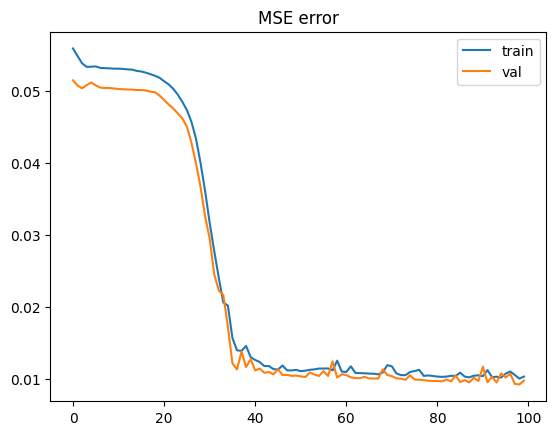

In [110]:
epochs = 100
history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
    train_loss /=len(train_loader.dataset)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)

    history.append((train_loss, val_loss))

    if (epoch+1)%5==0: print(f"Epoch {epoch:02d} | Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}")
plt.plot(range(len(history)), [l[0] for l in history], label='train')
plt.plot(range(len(history)), [l[1] for l in history], label='val')
plt.title('MSE error')
plt.legend()
plt.show()

RMSE: 0.09908828 R²: 0.8051773 MAE: 0.07830446


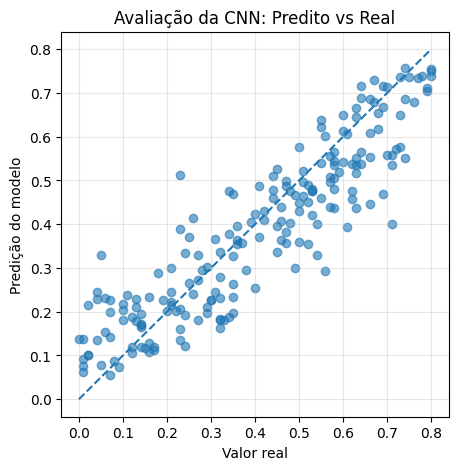

In [111]:
Xval = valDs.dataset.tensors[0][valDs.indices]#.squeeze().detach().cpu().numpy()
yval = valDs.dataset.tensors[1][valDs.indices].squeeze().detach().cpu().numpy()
# print(Xval.shape, yval.shape)

model.eval()
with torch.no_grad():
    y_pred = model(Xval).squeeze().detach().cpu().numpy()

# RMSE, R2, MAE
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
R2  = 1- mse/np.std(yval)**2
print("RMSE:", np.sqrt(mse), "R²:", R2, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Valor real")
plt.ylabel("Predição do modelo")
plt.title("Avaliação da CNN: Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

## RNN: GRU

In [79]:
train_df = pd.read_csv('data_train_DWT.csv', sep="\t")
test_df = pd.read_csv('data_test_DWT.csv', sep="\t")

In [80]:
X = torch.Tensor(np.array(train_df)[:,:-1]).unsqueeze(2)
y = torch.Tensor(np.array(train_df['y']).reshape(-1,1))

dataset = TensorDataset(X, y)
trainDs, valDs = random_split(dataset, [.8,.2])

train_loader = DataLoader(trainDs, batch_size=256, shuffle=True)
val_loader = DataLoader(valDs, batch_size=256, shuffle=False)
X.shape

torch.Size([1000, 2202, 1])

In [81]:
hidden_size = 16
gru = nn.GRU(input_size=1, hidden_size=hidden_size, num_layers=2, batch_first=True)
head = nn.Linear(hidden_size, 1)   # prediction head

# combine params from both "submodules"
optimizer = torch.optim.Adam(list(gru.parameters()) + list(head.parameters()), lr=1e-3)
criterion = nn.MSELoss()

epoch 01 | train MSE: 0.065550
epoch 02 | train MSE: 0.061722
epoch 03 | train MSE: 0.058463
epoch 04 | train MSE: 0.055820
epoch 05 | train MSE: 0.054288
epoch 06 | train MSE: 0.053327
epoch 07 | train MSE: 0.053487
epoch 08 | train MSE: 0.053595
epoch 09 | train MSE: 0.053774
epoch 10 | train MSE: 0.053770


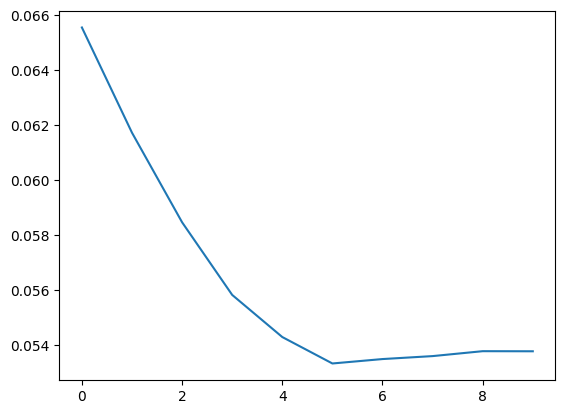

In [82]:
# ----- training loop -----
gru.train(); head.train()
loss_history = []
for epoch in range(10):
    train_loss = 0.0
    for xb, yb in train_loader:
        # forward (manual “forward”)
        out, h = gru(xb)               # out: (B, T, H), h: (1, B, H)
        feat = out[:, -1, :]           # OR: h[-1]  (both are (B, H))
        pred = torch.sigmoid(head(feat))  # keep in [0,1]

        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        
    loss_history.append(train_loss/len(train_loader.dataset))
    print(f"epoch {epoch+1:02d} | train MSE: {train_loss/len(train_loader.dataset):.6f}")
plt.plot(loss_history);

RMSE: 0.23506692 MAE: 0.2033291


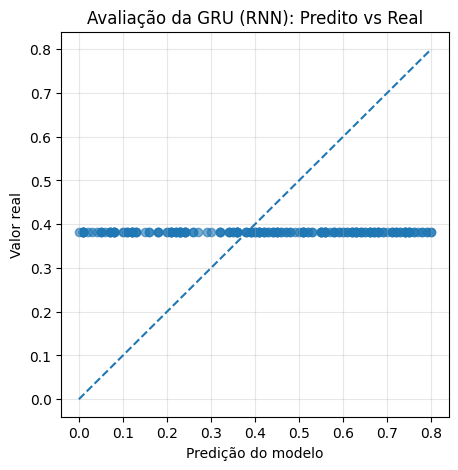

In [83]:
# ----- inference -----
gru.eval(); head.eval()
val_loss = 0
with torch.no_grad():
    for xb, yb in val_loader:
        out, h = gru(xb)
        feat = out[:, -1, :]
        y_pred = torch.sigmoid(head(feat))
        val_loss += criterion(y_pred, yb).item() * xb.size(0)
val_loss /= len(val_loader.dataset)

# RMSE, MAE
rmse = np.sqrt(np.mean((y_pred.squeeze().detach().cpu().numpy() - yval.reshape(-1,1))**2))
mae = np.mean(np.abs((y_pred.squeeze().detach().cpu().numpy() - yval.reshape(-1,1))))
print("RMSE:", rmse, "MAE:", mae)

# Gráfico de avaliação
plt.figure(figsize=(5, 5))
plt.scatter(yval, y_pred, alpha=0.6)

# Reta x = y (ideal)
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')

plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação da GRU (RNN): Predito vs Real")
plt.grid(True, alpha=0.3)
plt.show()

Horrível, RNN não funciona

## Random Forest

In [112]:
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.model_selection import train_test_split

X = np.array(train_df.iloc[:,:500])
y = np.array(train_df['y'])

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=.2)
print([s.shape for s in [X,y,Xtrain, Xval, ytrain, yval]])

[(1000, 500), (1000,), (800, 500), (200, 500), (800,), (200,)]


In [113]:
model = RFR(n_estimators=100, criterion='squared_error')
model.fit(Xtrain, ytrain)
y_pred, y_tr_pred = model.predict(Xval), model.predict(Xtrain)

RMSE: 0.09295636099805113 R²: 0.8430228548665584 MAE: 0.07211050000000001


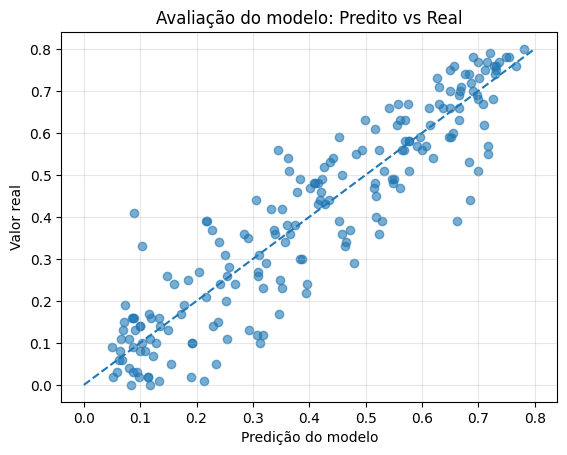

In [118]:
mse = np.mean((y_pred - yval)**2)
mae = np.mean(np.abs((y_pred - yval)))
print("RMSE:", np.sqrt(mse), "R²:", 1-mse/np.std(yval)**2,"MAE:", mae)

# Gráfico de avaliação
min_val = min(y_pred.min(), yval.min())
max_val = max(y_pred.max(), yval.max())

plt.scatter(y_pred, yval, alpha=0.6)
plt.plot([min_val, max_val], [min_val, max_val], '--')
plt.xlabel("Predição do modelo")
plt.ylabel("Valor real")
plt.title("Avaliação do modelo: Predito vs Real")
plt.grid(True, alpha=0.3)

plt.show()

Resultado fraco